In [1]:
import pandas as pd
from sklearn.metrics import root_mean_squared_error

In [ ]:
schema_nav_df = pd.read_parquet('data/clean/debt_schema_nav.parquet')

In [3]:
train_set = schema_nav_df[(schema_nav_df['Date'].dt.year >= 2018) & (schema_nav_df['Date'].dt.year <= 2024)]
test_set = schema_nav_df[schema_nav_df['Date'].dt.year > 2024]


In [4]:
test_set = test_set.copy()
test_set['Naive Forecast'] = (test_set['category_avg_nav'].shift(1).fillna(train_set['category_avg_nav'].iloc[-1]))
rmse = root_mean_squared_error(test_set['category_avg_nav'], 
                            test_set['Naive Forecast'])

print("RMSE: ", rmse)

RMSE:  69.20833150054922


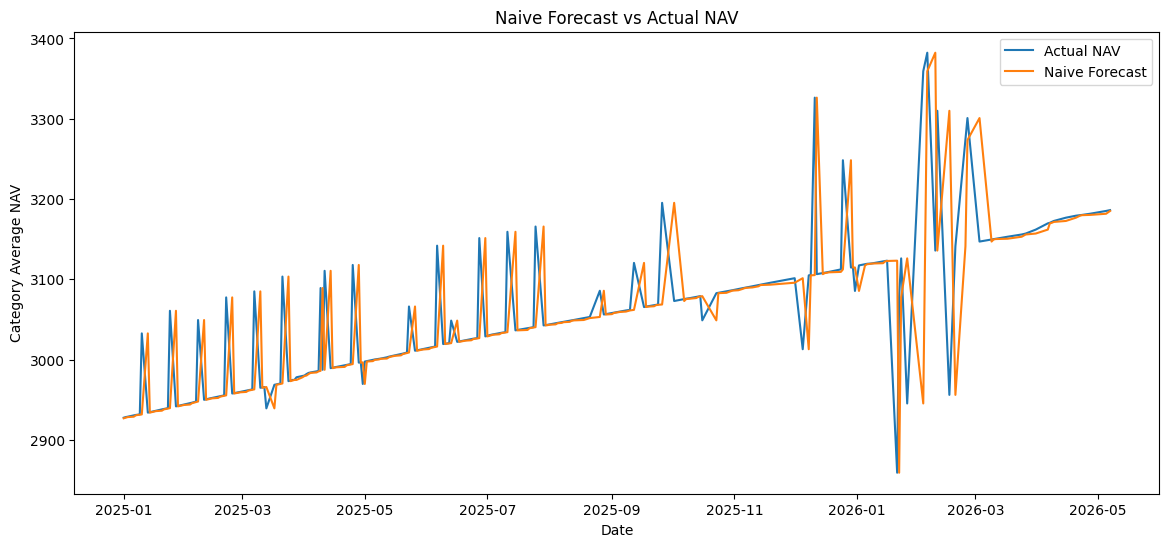

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label='Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['Naive Forecast'],
    label='Naive Forecast'
)

plt.title('Naive Forecast vs Actual NAV')
plt.xlabel('Date')
plt.ylabel('Category Average NAV')

plt.legend()

plt.show()

In [6]:
test_set['moving_average'] = (test_set['category_avg_nav']
                                    .shift(1)
                                    .fillna(train_set['category_avg_nav'].iloc[-1])
                                    .rolling(window=30, min_periods=1)
                                    .mean())

In [7]:
rolling_rmse = root_mean_squared_error(test_set['category_avg_nav'], test_set['moving_average'])

print("Rolling window RMSE: ", rolling_rmse)

Rolling window RMSE:  52.147542785983845


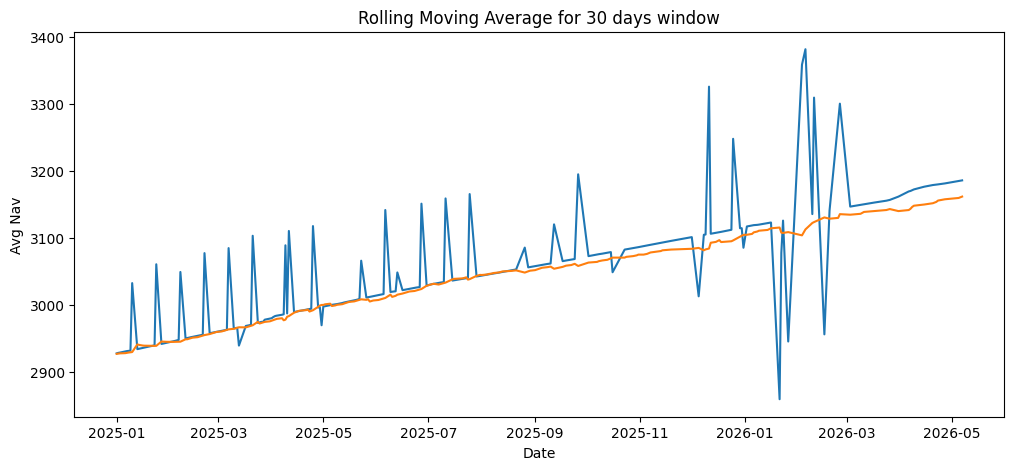

In [8]:
plt.figure(figsize = (12, 5))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label = 'Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['moving_average'],
    label = 'Moving Average'
)

plt.title('Rolling Moving Average for 30 days window')
plt.xlabel('Date')
plt.ylabel('Avg Nav')

plt.show()

In [9]:
test_set['moving_average_14'] = (test_set['category_avg_nav']
                                    .shift(1)
                                    .fillna(train_set['category_avg_nav'].iloc[-1])
                                    .rolling(window=14, min_periods=1)
                                    .mean())

rolling_14_rmse = root_mean_squared_error(test_set['category_avg_nav'], test_set['moving_average_14'])

print("Rolling window 14 RMSE: ", rolling_14_rmse)

Rolling window 14 RMSE:  52.10541132225447


In [10]:
test_set['moving_average_7'] = (test_set['category_avg_nav']
                                    .shift(1)
                                    .fillna(train_set['category_avg_nav'].iloc[-1])
                                    .rolling(window=7, min_periods=1)
                                    .mean())

rolling_7_rmse = root_mean_squared_error(test_set['category_avg_nav'], test_set['moving_average_7'])

print("Rolling window 7 RMSE: ", rolling_7_rmse)

Rolling window 7 RMSE:  53.2155552074235


| Model | RMSE | Behavior       |
| ----- | ---- | -------------- |
| Naive | 69.20    | reactive       |
| MA-30 | 52.14    | smooth/lagging |
| MA-14 | 52.10    | smooth/lagging |
| MA-7  | 53.21    | smooth/lagging |

In [12]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(
        
        train_set['category_avg_nav']
).fit()

In [13]:
ses_forecast = ses_model.forecast(len(test_set))

In [14]:
test_set['SES Forecast'] = ses_forecast.values

In [15]:
from sklearn.metrics import root_mean_squared_error

ses_rmse = root_mean_squared_error(
    test_set['SES Forecast'],
    test_set['category_avg_nav']
)

print("SES RMSE: ", ses_rmse)

SES RMSE:  140.5794999107068


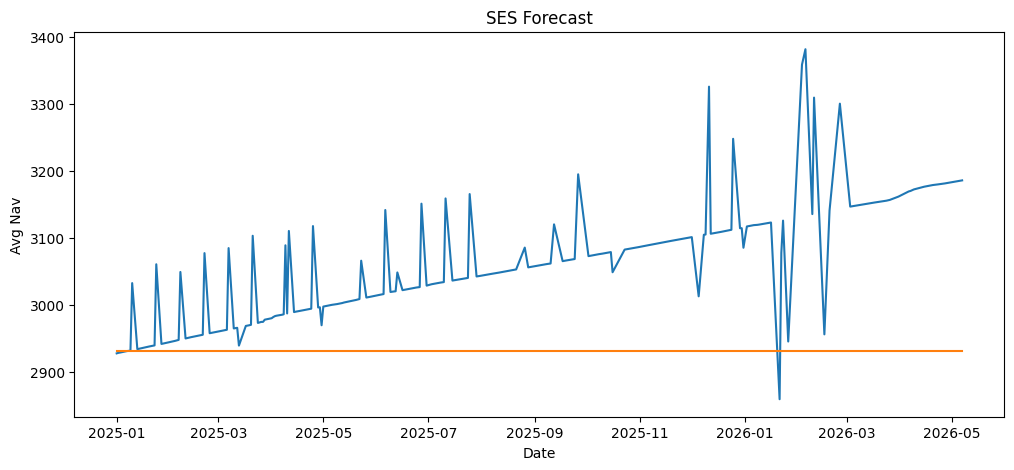

In [16]:
plt.figure(figsize = (12, 5))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label = 'Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['SES Forecast'],
    label = 'SES Forecast'
)

plt.title('SES Forecast')
plt.xlabel('Date')
plt.ylabel('Avg Nav')

plt.show()

| Model | RMSE | Behavior       |
| ----- | ---- | -------------- |
| Naive | 69.20    | reactive       |
| MA-30 | 52.14    | smooth/lagging |
| MA-14 | 52.10    | smooth/lagging |
| MA-7  | 53.21    | smooth/lagging |
| SES   | 140.57    | extremely smooth and declining |
| Holt  | 54.85     | smooth |


In [17]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(
    train_set['category_avg_nav']
).fit()

holt_forecast = holt_model.forecast(
    len(test_set)
)

test_set['Holt Forecast'] = holt_forecast.values

In [18]:
holt_rmse = root_mean_squared_error(test_set['category_avg_nav'], 
                            test_set['Holt Forecast'])

print("Holt RMSE: ", holt_rmse)

Holt RMSE:  54.85542796787063


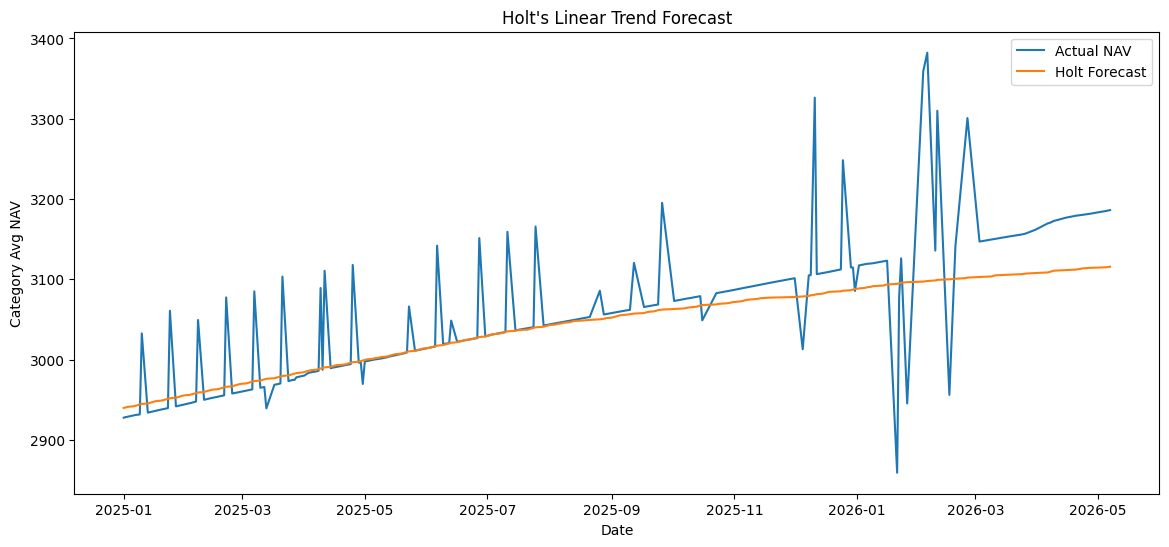

In [19]:
plt.figure(figsize=(14,6))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label='Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['Holt Forecast'],
    label='Holt Forecast'
)

plt.title("Holt's Linear Trend Forecast")
plt.xlabel('Date')
plt.ylabel('Category Avg NAV')

plt.legend()

plt.show()

In [20]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train_set['category_avg_nav'],
    order=(1,1,1)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    steps=len(test_set)
)

test_set['ARIMA Forecast'] = arima_forecast.values

arima_rmse = root_mean_squared_error(
    test_set['category_avg_nav'],
    test_set['ARIMA Forecast']
)



In [21]:
print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 140.4047342356764


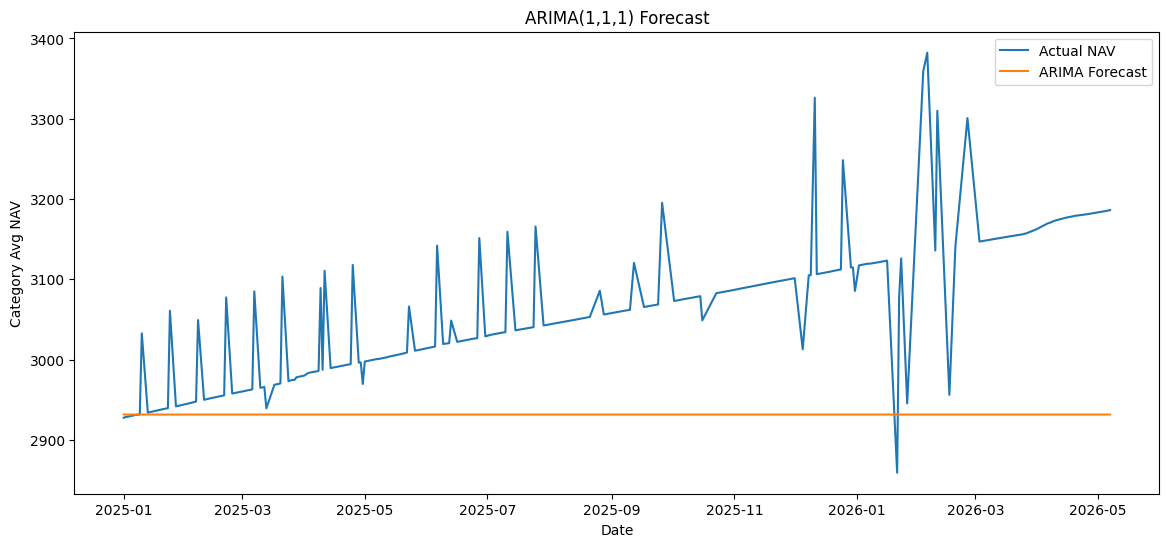

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label='Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['ARIMA Forecast'],
    label='ARIMA Forecast'
)

plt.title('ARIMA(1,1,1) Forecast')
plt.xlabel('Date')
plt.ylabel('Category Avg NAV')

plt.legend()

plt.show()

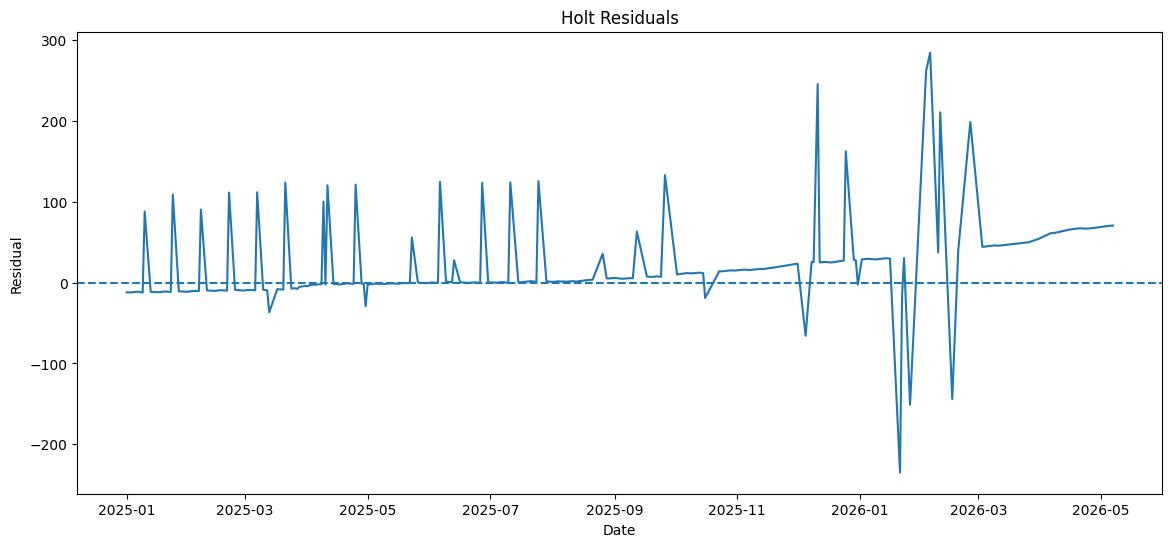

In [23]:
test_set['Holt Residuals'] = (
    test_set['category_avg_nav']
    - test_set['Holt Forecast']
)

plt.figure(figsize=(14,6))

plt.plot(
    test_set['Date'],
    test_set['Holt Residuals']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Holt Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

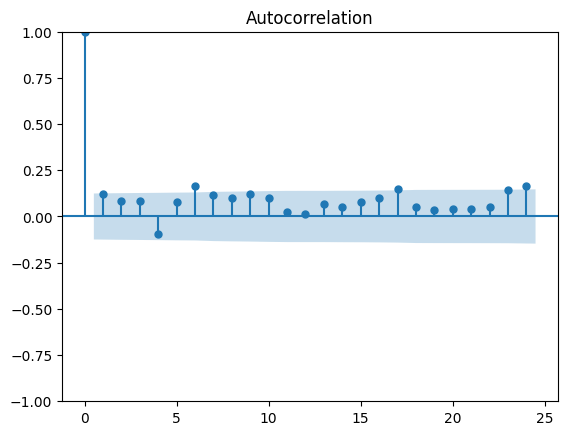

In [24]:
from statsmodels.graphics.tsaplots import plot_acf


plot_acf(
    test_set['Holt Residuals']
)

plt.show()